In [7]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt 

In [9]:
data_dir=Path('data')

data


In [10]:
customers = pd.read_csv(data_dir/'customers.csv',parse_dates=['DOB','SignupDate'])
accounts = pd.read_csv(data_dir/'accounts.csv',parse_dates=['OpenedDate'])
branches = pd.read_csv(data_dir/'branches.csv',parse_dates=['OpenedDate'])
loans = pd.read_csv(data_dir/'loans.csv',parse_dates=['IssueDate'])
cards = pd.read_csv(data_dir/'cards.csv')
transactions = pd.read_csv(data_dir/'transactions.csv',parse_dates=['TxnDate'])
merchants = pd.read_csv(data_dir/'merchants.csv')

In [11]:
customers.columns = ['customer_id', 'full_name', 'pan_number', 'dob', 'city',
                      'monthly_income', 'risk_score', 'kyc_status',
                      'signup_date', 'preferred_branch_id']

accounts.columns = ['account_id', 'customer_id', 'branch_id', 'account_type',
                     'status', 'opened_date', 'balance']

branches.columns = ['branch_id', 'city', 'ifsc', 'opened_date']

loans.columns = ['loan_id', 'customer_id', 'branch_id', 'loan_type',
                  'principal_amount', 'interest_rate_apr', 'tenure_months',
                  'status', 'issue_date']

cards.columns = ['card_id', 'customer_id', 'account_id', 'card_type',
                  'network', 'credit_limit', 'is_active']

transactions.columns = ['transaction_id', 'account_id', 'txn_datetime',
                         'txn_type', 'amount', 'merchant_id', 'channel']

merchants.columns = ['merchant_id', 'merchant_name', 'category', 'city']

print(customers.columns.tolist())

['customer_id', 'full_name', 'pan_number', 'dob', 'city', 'monthly_income', 'risk_score', 'kyc_status', 'signup_date', 'preferred_branch_id']


In [17]:
#1.trim extra spaces from city names and also fixing capitalization
for df in[customers,accounts,branches,merchants]:
    if 'city' in df.columns:
        df['city']=df['city'].str.strip().str.title()
customers['city'].unique()

array(['Delhi', 'Pune', 'Lucknow', 'Jaipur', 'Ahmedabad', 'Hyderabad',
       'Mumbai', 'Kolkata', 'Chandigarh', 'Bengaluru', 'Surat', 'Chennai'],
      dtype=object)

In [19]:
# 2. for impossible negative balances 
accounts['balance'].sort_values().head()

27716   -50000.0
75517   -50000.0
55887   -50000.0
34722   -50000.0
19626   -50000.0
Name: balance, dtype: float64

In [24]:
#3. for duplicate pan no.
duplicate_pan_count=customers['pan_number'].duplicated().sum()
duplicate_pan_count

np.int64(0)

In [29]:
# 4. transactions with no account id or zero amount
missing_account=transactions['account_id'].isnull().sum()
zero_amount=(transactions['amount']==0).sum()
missing_account
zero_amount

np.int64(0)

In [33]:
#KPIs
total_customers=customers['customer_id'].nunique()
active_accounts=accounts[accounts['status']=='Active']['account_id'].nunique()
total_loans=loans.shape[0]
total_cards=cards.shape[0]
avg_risk_score=customers['risk_score'].mean()
total_balance=accounts['balance'].sum()

In [36]:
kpi_summary = {
    'Total Customers': total_customers,
    'Active Accounts': active_accounts,
    'Total Loans': total_loans,
    'Total Cards': total_cards,
    'Average Risk Score': round(avg_risk_score, 2),
    'Total Balance': round(total_balance, 2)
}
kpi_summary

{'Total Customers': 60000,
 'Active Accounts': 71894,
 'Total Loans': 15000,
 'Total Cards': 50000,
 'Average Risk Score': np.float64(649.43),
 'Total Balance': np.float64(6367497803.54)}

In [43]:
#Monthly Tansaction Trends
transactions['txn_month']=transactions['txn_datetime'].dt.to_period('M')

txn_count_by_month=transactions.groupby('txn_month')['transaction_id'].count()
txn_amount_by_month = transactions.groupby('txn_month')['amount'].sum()

monthly_summary = pd.DataFrame({
    'total_txns':txn_count_by_month,
    'net_amount':txn_amount_by_month
}).reset_index()
monthly_summary['txn_month'] = monthly_summary['txn_month'].astype(str)
monthly_summary.head()

,txn_month,total_txns,net_amount
0,2022-01,4167,-8728285.74
1,2022-02,3820,-8093948.23
2,2022-03,4097,-9122540.10
3,2022-04,4020,-8466151.56
4,2022-05,4149,-9346586.25


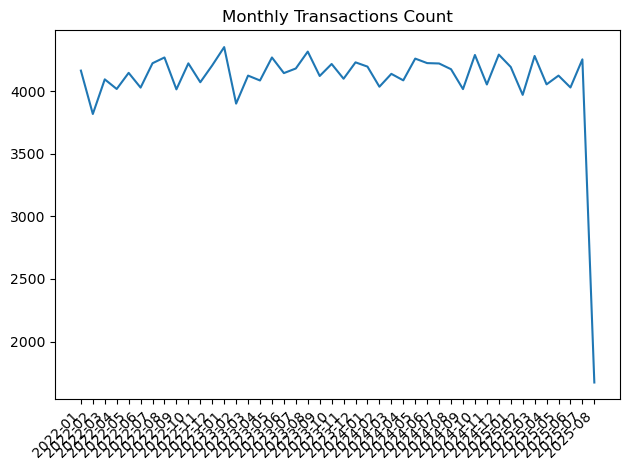

In [45]:
#Visuals 

plt.figure()
plt.plot(monthly_summary['txn_month'],monthly_summary['total_txns'])
plt.title('Monthly Transactions Count')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()    

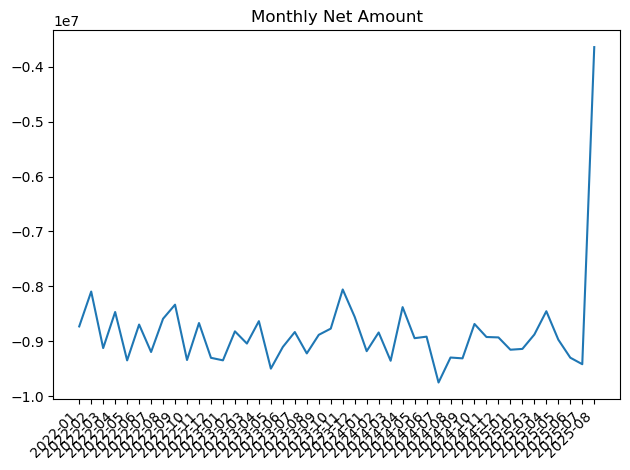

In [46]:
plt.figure()
plt.plot(monthly_summary['txn_month'], monthly_summary['net_amount'])
plt.title('Monthly Net Amount')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

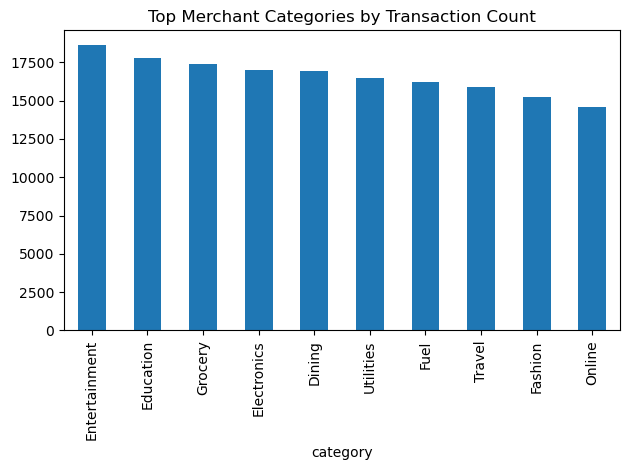

In [49]:
txn_with_merchant=transactions.merge(merchants,on='merchant_id',how='left')

category_counts=txn_with_merchant.groupby('category')['transaction_id'].count()
category_counts=category_counts.sort_values(ascending=False).head(10)

plt.figure()
category_counts.plot(kind='bar')
plt.title('Top Merchant Categories by Transaction Count')
plt.tight_layout()
plt.show()

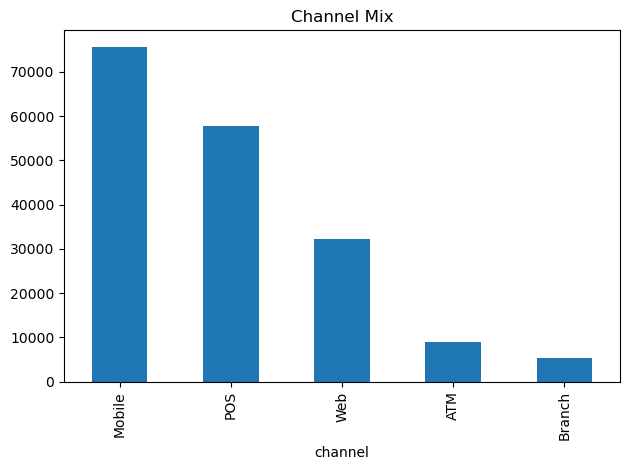

In [50]:
channel_counts = transactions.groupby('channel')['transaction_id'].count()
channel_counts = channel_counts.sort_values(ascending=False)

plt.figure()
channel_counts.plot(kind='bar')
plt.title('Channel Mix')
plt.tight_layout()
plt.show()

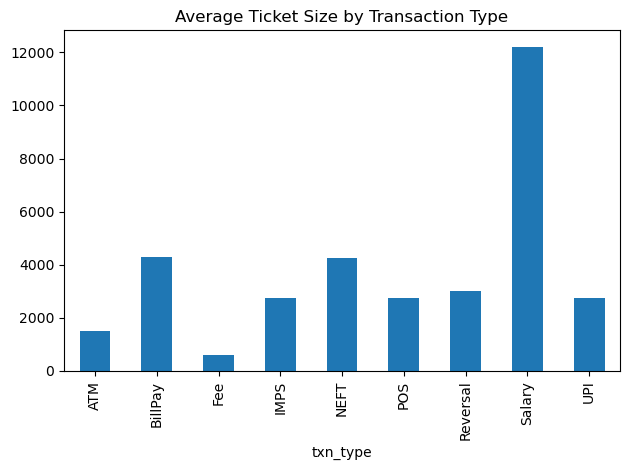

In [51]:
avg_ticket = transactions.groupby('txn_type')['amount'].apply(lambda x: x.abs().mean())

plt.figure()
avg_ticket.plot(kind='bar')
plt.title('Average Ticket Size by Transaction Type')
plt.tight_layout()
plt.show()

In [52]:
high_value_threshold = 50000

transactions['is_high_value'] = transactions['amount'].abs() > high_value_threshold

high_value_count = transactions['is_high_value'].sum()
print("Number of high-value transactions flagged:", high_value_count)

transactions[transactions['is_high_value']].head(10)

Number of high-value transactions flagged: 86


,transaction_id,account_id,txn_datetime,txn_type,amount,merchant_id,channel,txn_month,is_high_value
1786,30001787,200251,2023-04-02,Salary,61596.04,51060,Web,2023-04,True
5560,30005561,215784,2023-08-03,BillPay,-122717.04,50503,POS,2023-08,True
8386,30008387,214542,2025-04-18,BillPay,-76030.16,50789,POS,2025-04,True
12442,30012443,245274,2022-07-28,Salary,57955.19,50938,Mobile,2022-07,True
12868,30012869,214920,2022-02-13,POS,-51535.92,51011,ATM,2022-02,True
14124,30014125,264918,2024-01-22,IMPS,-69719.36,50209,Web,2024-01,True
14433,30014434,265776,2024-12-08,Salary,152195.12,50599,Mobile,2024-12,True
15017,30015018,233048,2022-07-21,BillPay,-51504.16,50703,Mobile,2022-07,True
21876,30021877,277565,2024-11-04,UPI,-65328.72,50308,POS,2024-11,True
22734,30022735,278859,2023-08-08,POS,-55545.60,51039,Mobile,2023-08,True


In [65]:
export_dir = Path('exports')

monthly_summary.to_csv(export_dir / 'monthly_summary.csv', index=False)

customer_balance = accounts.groupby('customer_id')['balance'].sum().reset_index()
customer_balance.columns = ['customer_id', 'total_balance']
customer_balance.to_csv(export_dir / 'customer_balance.csv', index=False)

branch_loan_summary = loans.groupby('branch_id').agg(
    total_loans=('loan_id', 'count'),
    total_principal=('principal_amount', 'sum'),
    avg_apr=('interest_rate_apr', 'mean')
).reset_index()
branch_loan_summary.to_csv(export_dir / 'branch_loan_summary.csv', index=False)

transactions[transactions['is_high_value']].to_csv(export_dir / 'high_value_transactions.csv', index=False)

print("done", export_dir.resolve())

done C:\Users\tbise\banking_project\exports
